# Report 2: Exploration of energy usage and devices

This report aims to use the provided data on electricity usage per month .

I don't think it makes sense to look at the same variable as the report elena & Miro are doing.

------------------------------

This report aims to use the provided data on electricity and gas usage, as well as the data on the devices that were installed in the house to provide an overview of the consumption of gas and electricity. This report aims to answer the question: are there time-related patterns that emerge from the gas and electricity consumptions?

We can start by importing the home messages file and creating the "myhome" database. Then we can insert the files into the database and return the data from the database as a pandas dataframe.

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [32]:
files = check_filepaths("P1e-*.csv.gz","P1e") + check_filepaths("P1e-*.csv","P1e")
for file in files:
    db.insert_table_P1e(file)

In [33]:
files = check_filepaths("smartthings*.tsv.gz","smartthings")

for file in files:
    db.insert_table_smartthings(file)

In [56]:
files = check_filepaths("P1g-*.csv.gz","P1g") + check_filepaths("P1g-*.csv","P1g")
for file in files:
    db.insert_table_P1g(file)

And now fetch them and insert them into a pandas dataframe

In [57]:
smart_things = db.return_whole_table("smartthings")
p1e = db.return_whole_table("P1e")
p1g = db.return_whole_table("P1g")
p1g.head()

,epoch,Total_gas_used
0,1647612900,3422.015
1,1647613800,3422.028
2,1647614700,3422.033
3,1647615600,3422.065
4,1647616500,3422.089


In [37]:
p1e.describe()

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2
count,1.060010e+05,106001.000000,106001.000000,106001.0,106001.0
mean,1.695370e+09,9695.200946,7639.416619,0.0,0.0
std,2.759659e+07,1851.160930,1396.233002,0.0,0.0
min,1.647613e+09,6506.377000,5313.255000,0.0,0.0
25%,1.671466e+09,8064.718000,6372.915000,0.0,0.0
50%,1.695320e+09,9638.794000,7582.401000,0.0,0.0
75%,1.719305e+09,11353.276000,8847.204000,0.0,0.0
max,1.743155e+09,12906.475000,10103.067000,0.0,0.0


In [59]:
p1e["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1e["year"] = p1e["date"].dt.year
p1e["month"] = p1e["date"].dt.month
p1e["day_as_date"]=p1e["date"].dt.date
p1e["Usage"] = (p1e["Electricity_imported_T1"].diff() + p1e["Electricity_imported_T2"].diff()).fillna(0)

p1g["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1g["year"] = p1g["date"].dt.year
p1g["month"] = p1g["date"].dt.month
p1g["day_as_date"]=p1g["date"].dt.date
p1g["Usage"] = (p1g["Total_gas_used"].diff()).fillna(0)

p1e_new = p1e.groupby(by=["day_as_date","year","month"], as_index = False)["Usage"].aggregate(total_usage_electricity = "sum")
p1g_new = p1g.groupby(by=["day_as_date","year","month"], as_index = False)["Usage"].aggregate(total_usage_gas = "sum")

df = p1e_new.merge(p1g_new, how = "outer", on = ["day_as_date", "year", "month"])
df.head()

,day_as_date,year,month,total_usage_electricity,total_usage_gas
0,2022-03-18,2022,3,7.015,1.377
1,2022-03-19,2022,3,12.783,4.094
2,2022-03-20,2022,3,13.625,4.078
3,2022-03-21,2022,3,7.939,3.785
4,2022-03-22,2022,3,8.241,3.129


In [ ]:
from sklearn.cluster import KMeans
ss = []

for i in range(1,11):
    k = KMeans(n_clusters = i, random_state=42).fit(df[["total_usage_gas","total_usage_electricity"]])
    ss.append(k.inertia_)

plt.plot([i for i in range(1,11)], ss, 'o-', color = "black")
plt.title("Scree plot of K against within cluster variance")
plt.xlabel("K")
plt.ylabel("W(k)")
plt.show()

model = KMeans(n_clusters = 3,random_state = 42).fit(df[["total_usage_gas","total_usage_electricity"]])
label = model.predict(df[["total_usage_gas","total_usage_electricity"]])
p1e_new["label"] = label

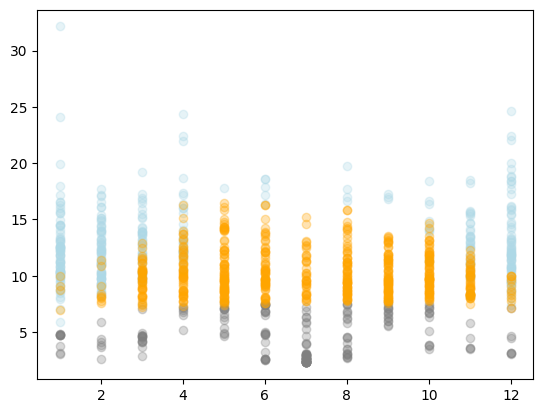

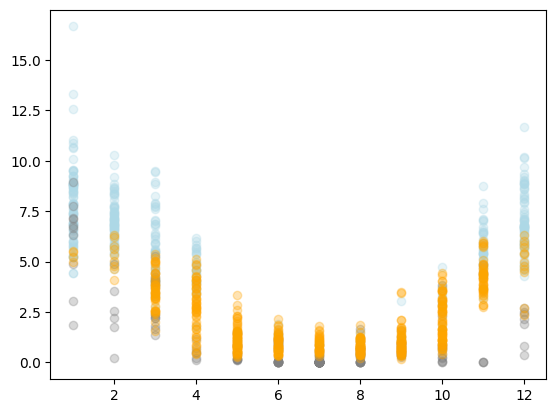

In [69]:
plt.scatter(df.loc[label == 0, "month"], df.loc[label == 0, "total_usage_electricity"], color = "lightblue", alpha = 0.3)
plt.scatter(df.loc[label == 1, "month"], df.loc[label == 1, "total_usage_electricity"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "month"], df.loc[label == 2, "total_usage_electricity"], color = "orange", alpha = 0.3)
plt.show()

plt.scatter(df.loc[label == 0, "month"], df.loc[label == 0, "total_usage_gas"], color = "lightblue", alpha = 0.3)
plt.scatter(df.loc[label == 1, "month"], df.loc[label == 1, "total_usage_gas"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "month"], df.loc[label == 2, "total_usage_gas"], color = "orange", alpha = 0.3)
plt.show()

In [ ]:
sns.histplot(p1e.Electricity_exported_T1)

In [ ]:
signal = smart_things[smart_things.attribute == "rssi"]
signal


Average over each 60 seconds to have measurements per minute

In [ ]:
#plt.scatter(signal.epoch,signal.value_int)
sns.scatterplot(signal[1:5000], x = "epoch", y = "value_int")